# Performing curation of all imodulons at once now.

- Based on GRN, OrthoICA, and functional annotation, I will rename all imodulons all at once
- If manual changes to the imodulon names after new insights from subsequent analysis, go directly to the end <br>
- **NOTE: Use previous ica_data to characterize the new imodulons rather than perform manual work**

In [36]:
from pymodulon.io import *
from pymodulon.plotting import *

from pymodulon.enrichment import compute_enrichment, compute_annotation_enrichment

import os
from os import path

import pandas as pd

from matplotlib import cm, colors as mcolors
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

### path to different data

In [37]:
data_dir = path.join('..', 'ctherm_nf','processed_data')
interim_dir = path.join('..', 'ctherm_nf', 'interim')
external_dir = path.join('..', 'ctherm_nf', 'external')

### different required data need to be loaded including previous processed ICA_DATA FILE

In [38]:
ica_data = load_json_model(path.join(interim_dir,'ctherm_raw.json.gz'))

/Users/skd6150/Applications/anaconda3/envs/modulome_mac/lib/python3.9/site-packages/pymodulon/util.py:31: FutureWarning: Passing literal json to 'read_json' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  table = pd.read_json(table)
/Users/skd6150/Applications/anaconda3/envs/modulome_mac/lib/python3.9/site-packages/pymodulon/util.py:31: FutureWarning: Passing literal json to 'read_json' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  table = pd.read_json(table)
/Users/skd6150/Applications/anaconda3/envs/modulome_mac/lib/python3.9/site-packages/pymodulon/util.py:31: FutureWarning: Passing literal json to 'read_json' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  table = pd.read_json(table)
/Users/skd6150/Applications/anaconda3/envs/modulome_mac/lib/python3.9/site-packages/p

In [33]:
# also load previous one
ica_data_prev = load_json_model(path.join(data_dir,'ctherm_prev.json.gz'))
df_rename_imod = pd.read_csv('../5_characterize_iModulons/results_characterize_imodulons/imod_rename_mapping.tsv', sep='\t', index_col=0)

dict_rename_imod = df_rename_imod[['IM']].to_dict()['IM']

# rename all at once
ica_data_prev.rename_imodulons(dict_rename_imod)

/Users/skd6150/Applications/anaconda3/envs/modulome_mac/lib/python3.9/site-packages/pymodulon/util.py:31: FutureWarning: Passing literal json to 'read_json' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  table = pd.read_json(table)
/Users/skd6150/Applications/anaconda3/envs/modulome_mac/lib/python3.9/site-packages/pymodulon/util.py:31: FutureWarning: Passing literal json to 'read_json' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  table = pd.read_json(table)
/Users/skd6150/Applications/anaconda3/envs/modulome_mac/lib/python3.9/site-packages/pymodulon/util.py:31: FutureWarning: Passing literal json to 'read_json' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  table = pd.read_json(table)
/Users/skd6150/Applications/anaconda3/envs/modulome_mac/lib/python3.9/site-packages/p

In [5]:
# Get genes for each iModulon

df_prev_new_imod_map = pd.DataFrame(columns=['IM', 'IM_prev', 'IM_prev_category', 'IM_prev_source', 'f1_score', 'pval'])

dict_imodulon_genes = {im: ica_data.view_imodulon(im).index.tolist()
                  for im in ica_data.imodulon_names}

dict_imodulon_genes_prev = {im: ica_data_prev.view_imodulon(im).index.tolist()
                  for im in ica_data_prev.imodulon_names}


im_reg = list()
for imod_prev, genes_prev in dict_imodulon_genes_prev.items():
    for imod, genes in dict_imodulon_genes.items():
        if isinstance(ica_data.imodulon_table.loc[imod, 'regulator'], str):
            print(f'{imod} is regulatory')
            im_reg.append(imod)
        else:
            res = compute_enrichment(genes_prev, 
                                    genes,
                                    ica_data.gene_names)
            if res.pvalue < 0.05 and res.f1score>0.7:
                category_prev = df_rename_imod.loc[df_rename_imod.IM==imod_prev, 'category'].values[0]
                source_prev = df_rename_imod.loc[df_rename_imod.IM==imod_prev, 'source'].values[0]
                
                df_prev_new_imod_map.loc[len(df_prev_new_imod_map)] = imod, imod_prev, category_prev, source_prev, res.f1score, res.pvalue
            

im_reg = list(dict.fromkeys(im_reg))
df_prev_new_imod_map.sort_values('IM', inplace=True)

7 is regulatory
42 is regulatory
56 is regulatory
66 is regulatory
7 is regulatory
42 is regulatory
56 is regulatory
66 is regulatory
7 is regulatory
42 is regulatory
56 is regulatory
66 is regulatory
7 is regulatory
42 is regulatory
56 is regulatory
66 is regulatory
7 is regulatory
42 is regulatory
56 is regulatory
66 is regulatory
7 is regulatory
42 is regulatory
56 is regulatory
66 is regulatory
7 is regulatory
42 is regulatory
56 is regulatory
66 is regulatory
7 is regulatory
42 is regulatory
56 is regulatory
66 is regulatory
7 is regulatory
42 is regulatory
56 is regulatory
66 is regulatory
7 is regulatory
42 is regulatory
56 is regulatory
66 is regulatory
7 is regulatory
42 is regulatory
56 is regulatory
66 is regulatory
7 is regulatory
42 is regulatory
56 is regulatory
66 is regulatory
7 is regulatory
42 is regulatory
56 is regulatory
66 is regulatory
7 is regulatory
42 is regulatory
56 is regulatory
66 is regulatory
7 is regulatory
42 is regulatory
56 is regulatory
66 is regula

In [6]:
# remaining IMs
im_remaining = [k for k in ica_data.imodulon_names if not ((k in df_prev_new_imod_map.IM.values) or (k in im_reg))]
im_remaining

[57, 61, 64, 65]

### other gene information required

In [7]:
### gene info
df_gene_info = pd.read_csv(path.join(data_dir, 'gene_info.csv'), index_col=0)
df_gene_info.head()

,gene_name,accession,old_locus_tag,start,end,strand,gene_product,COG,uniprot,operon,GO_MF,GO_BP,InterPro,PFAMs
locus_tag,,,,,,,,,,,,,,
Clo1313_0001,dnaA,CP002416.1,NaN,212,1543,+,chromosomal replication initiator protein DnaA,No COG annotation,UPI0001B1F046,Op0,ATP binding; DNA replication origin binding; l...,DNA replication initiation; regulation of DNA ...,AAA+_ATPase;Chromosome_initiator_DnaA;Chromoso...,NaN
Clo1313_0002,RS00015,CP002416.1,NaN,1793,2893,+,DNA polymerase III%2C beta subunit,No COG annotation,UPI00017E1F7F,Op1,NaN,NaN,DNA_clamp_sf;DNA_polIII_beta;DNA_polIII_beta_C...,NaN
Clo1313_0003,yaaA,CP002416.1,NaN,2909,3115,+,S4 domain protein YaaA,No COG annotation,UPI000038F4E6,Op1,NaN,NaN,RNA-bd_S4-rel_YaaA;S4_RNA-bd;S4_RNA-bd_sf;,NaN
Clo1313_0004,recF,CP002416.1,NaN,3133,4242,+,DNA replication and repair protein RecF,No COG annotation,UPI00003C8C54,Op1,ATP binding; single-stranded DNA binding,DNA replication; DNA synthesis involved in DNA...,DNA-binding_RecF;DNA-binding_RecF_CS;P-loop_NT...,NaN
Clo1313_0005,RS00030,CP002416.1,NaN,4410,4724,+,hypothetical protein,Function unknown,UPI000038F4E8,Op2,NaN,NaN,RemA-like;,DUF370


In [39]:
DF_enrichments = pd.read_csv(path.join(data_dir,'functional_enrichments.csv'),index_col=0)
DF_enrichments.head()

,imodulon,annotation,pvalue,qvalue,precision,recall,f1score,TP,target_set_size,imodulon_size,source,pathway_name,module_name
0,2,L-tryptophan biosynthesis,2.510499e-11,4.744843e-09,0.800000,0.666667,0.727273,4.0,6.0,5.0,biocyc,NaN,NaN
1,7,"(1,4)-&beta;-D-xylan degradation",9.408885e-04,8.891397e-02,0.068966,0.400000,0.117647,2.0,5.0,29.0,biocyc,NaN,NaN
2,7,cellulose and hemicellulose degradation (cellu...,9.408885e-04,8.891397e-02,0.068966,0.400000,0.117647,2.0,5.0,29.0,biocyc,NaN,NaN
3,10,fatty acid biosynthesis initiation (type II),6.927798e-07,1.309354e-04,0.230769,0.600000,0.333333,3.0,5.0,13.0,biocyc,NaN,NaN
4,10,even <i>iso</i>-branched-chain fatty acid bios...,3.849618e-06,3.637889e-04,0.230769,0.375000,0.285714,3.0,8.0,13.0,biocyc,NaN,NaN


In [40]:
DF_enrichments.loc[DF_enrichments.source=='GRN']

,imodulon,annotation,pvalue,qvalue,precision,recall,f1score,TP,target_set_size,imodulon_size,source,pathway_name,module_name
0,7,Sigma-16,3.426805e-12,6.168249e-11,0.241379,0.583333,0.341463,7.0,12.0,29.0,GRN,NaN,NaN
1,7,Sigma-13,3.534914e-06,3.181422e-05,0.103448,0.750000,0.181818,3.0,4.0,29.0,GRN,NaN,NaN
2,7,Sigma-17,9.585634e-05,5.751380e-04,0.068966,1.000000,0.129032,2.0,2.0,29.0,GRN,NaN,NaN
3,25,LexA_1449,1.959852e-05,3.527733e-04,0.200000,0.094595,0.128440,7.0,74.0,35.0,GRN,NaN,NaN
4,25,Xre_0026,1.418118e-03,1.276306e-02,0.114286,0.095238,0.103896,4.0,42.0,35.0,GRN,NaN,NaN
5,25,Fur_1691,1.600079e-02,9.600477e-02,0.085714,0.066667,0.075000,3.0,45.0,35.0,GRN,NaN,NaN
6,39,Xre_2225,1.936015e-04,3.484826e-03,0.048780,1.000000,0.093023,2.0,2.0,41.0,GRN,NaN,NaN
7,42,BlaI_0696,1.105424e-06,1.989763e-05,0.150000,0.750000,0.250000,3.0,4.0,20.0,GRN,NaN,NaN
8,46,TetR_0692,2.019076e-04,3.634337e-03,0.056338,0.228571,0.090395,8.0,35.0,142.0,GRN,NaN,NaN
9,48,GlyR3,5.510798e-05,9.919436e-04,0.153846,0.666667,0.250000,2.0,3.0,13.0,GRN,NaN,NaN


#### individual imodulons, for the ones that I could not identify the right imodulon names, iteratively went through each and then changed thresholds if needed

In [45]:
imod_of_interest = 'TetR_0692'
# for x in ica_data.view_imodulon(imod_of_interest).sort_values('gene_weight', ascending=False).index.to_list():
#     print(x)
ica_data.view_imodulon(imod_of_interest).sort_values(['gene_weight', 'operon'], ascending=False).head(20)

KeyError: 'TetR_0692'

In [14]:
DF_enrichments[DF_enrichments.imodulon==imod_of_interest].sort_values('f1score',ascending=False)

,imodulon,annotation,pvalue,qvalue,precision,recall,f1score,TP,target_set_size,imodulon_size,source,pathway_name,module_name


<Axes: ylabel='57 iModulon\nActivity'>

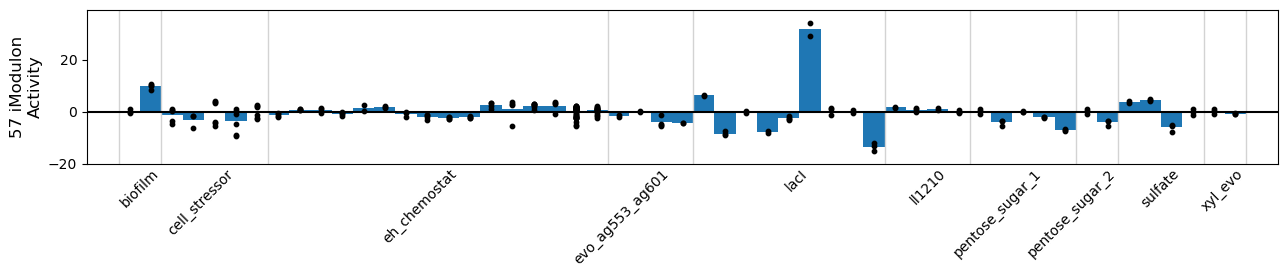

In [15]:
plot_activities(ica_data, imod_of_interest)

/Users/skd6150/Applications/anaconda3/envs/modulome_mac/lib/python3.9/site-packages/sklearn/tree/_classes.py:366: FutureWarning: Criterion 'mae' was deprecated in v1.0 and will be removed in version 1.2. Use `criterion='absolute_error'` which is equivalent.
  warnings.warn(


<Axes: xlabel='57'>

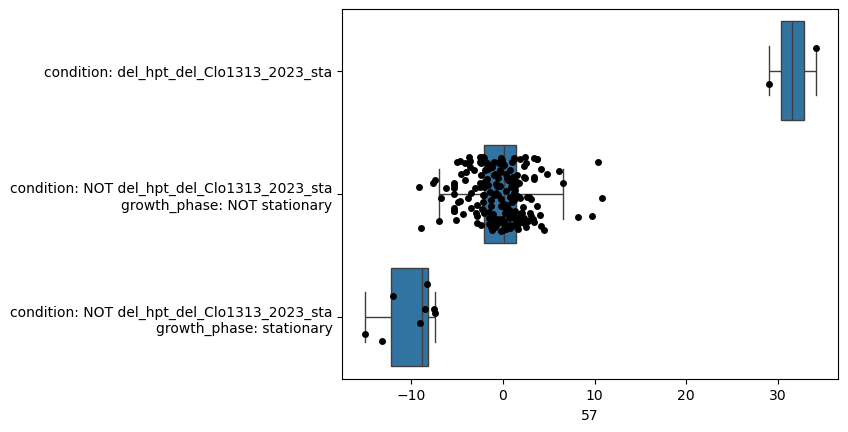

In [16]:
# Metadata boxplot
metadata_boxplot(ica_data, imod_of_interest)

## Adjust some thresholds -- if no genes present (62, 53)

Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


Text(13.222222222222216, 0.5, 'Gene Weights')

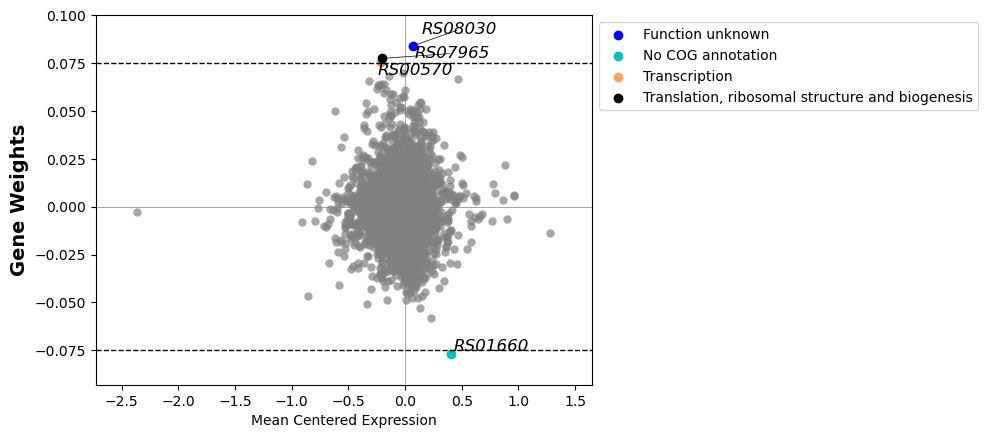

In [17]:
# imod_of_interest = 50
ax = plot_gene_weights(ica_data, imod_of_interest, by='log-tpm-norm')

labels_of_interest = list() #any labels that I would like to keep

# for t in ax.texts:
#     if t.get_text() not in labels_of_interest:
#         t.remove()


ax.set_ylabel('Gene Weights', fontdict={'weight':'bold', 'size':14})

In [10]:
dict_change_threshold = {57: 0.075,
                        #  53: 0.075
                        }

for imod, new_thres in dict_change_threshold.items():
    ica_data.change_threshold(imod, new_thres)

# Recalculate enrichments
ica_data.compute_trn_enrichment([k for k in dict_change_threshold.keys()], save=True)

,imodulon,regulator,pvalue,qvalue,precision,recall,f1score,TP,regulon_size,imodulon_size,n_regs


In [18]:
ica_data.view_imodulon(imod_of_interest)

,gene_weight,gene_name,accession,old_locus_tag,start,end,strand,gene_product,COG,uniprot,operon,GO_MF,GO_BP,InterPro,PFAMs,regulator
Clo1313_0107,0.075290,RS00570,CP002416.1,NaN,122010,122453,+,transcriptional regulator%2C BadM/Rrf2 family,Transcription,UPI00003C8E1E,Op79,NaN,NaN,Tscrpt_reg_Rrf2;WH-like_DNA-bd_sf;WH_DNA-bd_sf;,Rrf2,NaN
Clo1313_0322,-0.076899,RS01660,CP002416.1,NaN,353207,353581,+,hypothetical protein,No COG annotation,UPI000038FB52,Op214,NaN,NaN,NaN,-,NaN
Clo1313_1578,0.077399,RS07965,CP002416.1,NaN,1835747,1837387,+,glutamyl-tRNA synthetase,"Translation, ribosomal structure and biogenesis",UPI00003C8F4E,Op1095,NaN,NaN,aa-tRNA-synth_I_cd-bd;aa-tRNA-synth_I_codon-bd...,tRNA-synt_1c,AraC_0222
Clo1313_1591,0.083944,RS08030,CP002416.1,NaN,1855017,1855265,+,hypothetical protein,Function unknown,UPI00003C8CA0,Op1105,NaN,NaN,Ubiquitin-like_dom;Ubiquitin-like_domsf;YukD-l...,YukD,NaN


### check for expression vs activity correlation

In [19]:
from scipy.stats import pearsonr, spearmanr

In [20]:
df_metadata = ica_data.sample_table
df_expression = ica_data.X

df_corr = pd.DataFrame(columns=['corr', 'annotation', 'cog'])

for loctag_interest in ica_data.view_imodulon(imod_of_interest).index.to_list():
    df_metadata_eh = df_metadata.copy()
    exp_of_interest = df_metadata_eh.index.to_list()
    df_expression_eh = df_expression[exp_of_interest]
    values = df_expression_eh.loc[loctag_interest, :]

    x = values
    y = ica_data.A[exp_of_interest].loc[imod_of_interest]

    corr, p = pearsonr(x,y)
    corr, p = np.round(corr, 2), np.round(p, 2)

    if p<0.05 and corr>=0.5:
        print(loctag_interest, corr, p)
        prod = df_gene_info.loc[loctag_interest, 'gene_product']
        cog = ica_data.view_imodulon(imod_of_interest).loc[loctag_interest, 'COG']
        df_corr.loc[loctag_interest]= corr, prod, cog

df_corr.sort_values('corr', inplace=True, ascending=True)

Clo1313_1578 0.73 0.0
Clo1313_1591 0.68 0.0


In [21]:
print(imod_of_interest)
df_corr

57


,corr,annotation,cog
Clo1313_1591,0.68,hypothetical protein,Function unknown
Clo1313_1578,0.73,glutamyl-tRNA synthetase,"Translation, ribosomal structure and biogenesis"


### rename dictioanry that will be used to create the final DF

In [22]:
# manual changes
dict_rename_imod = {
                    1: ['SigG', 'functional', 'activity_expression_genes_present'],
                    57: ['GlyR1-Sta', 'activity_boxplot', 'metadata_boxplot'],
                    61: ['HighTemp-Sta', 'activity_boxplot', 'metadata_boxplot'],
                    64: ['UC', '', ''],
                    65: ['CheR-Related', 'functional', 'activity_expression_genes_present']                  

}


In [23]:
for im in im_reg:
    reg_name = ica_data.imodulon_table.loc[im, 'regulator']
    dict_rename_imod.update({im: [reg_name, 'regulatory', '']})

In [25]:
# create the new df_rename_imod
df_rename_imod_v2 = df_prev_new_imod_map.copy()

# df_remaining
df_remaining = pd.DataFrame.from_dict(dict_rename_imod, orient='index', columns = ['IM_name', 'category', 'source'])
df_remaining.reset_index(inplace=True)
# making df_remaining align with df_rename_imod_v2
df_remaining.columns = ['IM', 'IM_prev', 'IM_prev_category', 'IM_prev_source']

# concat
df_rename_imod_v2 = pd.concat([df_rename_imod_v2, df_remaining], axis=0)

# drop duplicates, keep last as those are manual
df_rename_imod_v2.drop_duplicates(subset=['IM'], keep='last', inplace=True)

# Change remaining UC to UC-5
df_rename_imod_v2.loc[df_rename_imod_v2['IM_prev']=='UC', 'IM_prev'] = 'UC-5'

# # # fill category with uncharacterized
df_rename_imod_v2.loc[df_rename_imod_v2['IM_prev'].str.match(r'^UC-\d+'), 'IM_prev_category'] = 'uncharacterized'


df_rename_imod_v2.loc[df_rename_imod_v2.IM.duplicated()]


df_rename_imod_v2.columns = ['IM_num', 'IM', 'category', 'source', 'f1_Score', 'pval']
df_rename_imod_v2.set_index('IM_num', inplace=True)


In [26]:
df_rename_imod

,IM,category,source
1,UC-1,uncharacterized,NaN
3,UC-2,uncharacterized,NaN
4,UC-3,uncharacterized,NaN
5,Pentose,functional,kegg
8,UC-4,uncharacterized,NaN
...,...,...,...
44,PurR,orthoICA,multiple
46,Argininie,orthoICA,ec
36,hpt KO,single_gene,NaN
39,SG-0124,single_gene,NaN


In [27]:
df_rename_imod_v2

,IM,category,source,f1_Score,pval
IM_num,,,,,
0,DDE_Tnp_1_3,functional,pfam,0.982456,2.065409e-116
2,Tryptophan,functional,kegg,1.000000,0.000000e+00
3,UC-2,uncharacterized,NaN,0.838710,5.084692e-32
4,SG-0124,single_gene,NaN,0.857143,5.384954e-24
5,tRNA,functional,kegg,0.898876,6.019389e-82
...,...,...,...,...,...
65,CheR-Related,functional,activity_expression_genes_present,NaN,NaN
7,Sigma-16,regulatory,,NaN,NaN
42,BlaI_0696,regulatory,,NaN,NaN


In [28]:
df_rename_imod_v2.loc[df_rename_imod_v2.IM=='Sulfate']

,IM,category,source,f1_Score,pval
IM_num,,,,,
30,Sulfate,functional,kegg,0.8,5.023763e-12


In [29]:
### save
df_rename_imod_v2.to_csv('./results_characterize_imodulons/imod_rename_mapping.tsv', sep='\t')

# Save final ICA data object as the gene thresholds have changed -- Don't save it for now. Do not change thresholds, if not needed.

In [30]:
save_to_json(ica_data, path.join(data_dir, 'ctherm.json.gz')) #adjusted
ica_data.imodulon_table.to_csv(path.join(data_dir, 'imodulon_table.csv'))

### If need to come back to rename imodulons, do it here

In [1]:
import pandas as pd
from os import path

In [2]:
data_dir = path.join('..', 'ctherm_nf','processed_data')
interim_dir = path.join('..', 'ctherm_nf', 'interim')
external_dir = path.join('..', 'ctherm_nf', 'external')

In [3]:
df_enrichments = pd.read_csv(path.join(data_dir,'functional_enrichments.csv'), index_col=1)

In [4]:
df_rename_imod = pd.read_csv('./results_characterize_imodulons/imod_rename_mapping.tsv', sep='\t', index_col=0)

In [5]:
dict_rename = {'FliA': 'SigD'
               
}

In [6]:
# rename here
for k,v in dict_rename.items():
    df_rename_imod.loc[df_rename_imod.IM==k, 'IM'] = v

In [7]:
# checking
for k,v in dict_rename.items():
    print(k, df_rename_imod.loc[df_rename_imod.IM==k])
    print(v, df_rename_imod.loc[df_rename_imod.IM==v])


FliA Empty DataFrame
Columns: [IM, category, source, f1_Score, pval]
Index: []
SigD           IM  category source  f1_Score           pval
IM_num                                                
8       SigD  orthoICA     ec   0.97931  1.472894e-139


In [8]:
### save again
df_rename_imod.to_csv('./results_characterize_imodulons/imod_rename_mapping.tsv', sep='\t')

## FIN

# Add biological functions
This is only relevant for 'biological' and 'regulatory iModulons

In [ ]:
subti_annot = pd.read_csv(path.join('..','data','external','subtiwiki_categories.csv'))
subti_annot.rename({'BSU_number':'gene_id'},axis=1,inplace=True)
subti_annot = subti_annot[subti_annot.gene_id.isin(ica_data.gene_names)]

In [ ]:
subti_enrich = ica_data.compute_annotation_enrichment(subti_annot,'FuncName2')
functions = subti_enrich.sort_values('qvalue').drop_duplicates('imodulon').set_index('imodulon')['FuncName2']
functions = functions[ica_data.imodulon_table.category.isin(['regulatory','functional'])]
functions.head()

In [ ]:
ica_data.imodulon_table['function'] = functions

## Manually curate functions

In [ ]:
ica_data.imodulon_table.function.value_counts()

In [ ]:
rename = {'carbon metabolism':'Carbon Metabolism',
          'coping with stress':'Stress Response',
          'amino acid/ nitrogen metabolism':'AA/Nucleotide Metabolism',
          'prophages':'Prophages',
          'sporulation':'Lifestyles',
          'exponential and early post-exponential lifestyles':'Lifestyles',
          'electron transport and ATP synthesis': 'Misc. Metabolism',
          'homeostasis':'Homeostasis',
          'nucleotide metabolism':'AA/Nucleotide Metabolism',
          'proteins of unknown function':'Other',
          'additional metabolic pathways':'Misc. Metabolism',
          'short peptides':'Cellular Processes',
          'essential genes':'Cellular Processes',
          'transporters':'Misc. Metabolism',
          'mobile genetic elements': 'Cellular Processes',
          'ncRNA':'Cellular Processes',
          'mobile genetic elements/ based on similarity':'Cellular Processes',
          'lipid metabolism':'Misc. Metabolism',
          'cell envelope and cell division': 'Cellular Processes',
          'genetics':'Cellular Processes'}

In [ ]:
ica_data.imodulon_table.function = ica_data.imodulon_table.function.replace(rename)

In [ ]:
ica_data.imodulon_table.loc['ybc-operon','function'] = 'Prophages'
ica_data.imodulon_table.loc['SigI','function'] = 'Stress Response'
ica_data.imodulon_table.loc['LnrK','function'] = 'Cellular Processes'
ica_data.imodulon_table.loc['early-biofilm','function'] = 'Lifestyles'
ica_data.imodulon_table.loc['KipR','function'] = 'Misc. Metabolism'
ica_data.imodulon_table.loc['AbrB','function'] = 'Lifestyles'
ica_data.imodulon_table.loc['putative-cssRS','function'] = 'Lifestyles'
ica_data.imodulon_table.loc['YvaF','function'] = 'Other'

In [ ]:
ica_data.imodulon_table.function.value_counts()

## Fill in Uncharacterized and Single Gene iModulons

In [ ]:
ica_data.imodulon_table.function = ['Uncharacterized' if row.category == 'uncharacterized' else
                                    'Single Gene' if row.category == 'single_gene' else row.function
                                    for i,row in ica_data.imodulon_table.iterrows()]


# Save final ICA data object

In [ ]:
save_to_json(ica_data, path.join(data_dir, 'bsu.json.gz'))

In [ ]:
ica_data.imodulon_table.to_csv(path.join(data_dir, 'imodulon_table.csv'))